In [68]:
import numpy as np
import pandas as pd

df = pd.read_csv('new_insurance_data.csv')    
print(df.head())

    age gender    bmi  children smoker  Claim_Amount  past_consultations  \
0  18.0   male  23.21       0.0     no   29087.54313                17.0   
1  18.0   male  30.14       0.0     no   39053.67437                 7.0   
2  18.0   male  33.33       0.0     no   39023.62759                19.0   
3  18.0   male  33.66       0.0     no   28185.39332                11.0   
4  18.0   male  34.10       0.0     no   14697.85941                16.0   

   num_of_steps  Hospital_expenditure  NUmber_of_past_hospitalizations  \
0      715428.0           4720920.992                              0.0   
1      699157.0           4329831.676                              0.0   
2      702341.0           6884860.774                              0.0   
3      700250.0           4274773.550                              0.0   
4      711584.0           3787293.921                              0.0   

   Anual_Salary     region    charges  
0   55784970.05  southeast  1121.8739  
1   13700885.19  s

In [69]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   gender                           1338 non-null   str    
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   str    
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   str    
 12  charges                        

In [70]:
print(df.isnull().sum())

age                                 9
gender                              0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64


In [71]:
age_mean = df['age'].mean()
bmi_mean = df['bmi'].mean()



In [72]:
df['age'] = df['age'].fillna(age_mean)
df['bmi'] = df['bmi'].fillna(bmi_mean)


In [73]:
df['children'] =   df['children'].fillna(df['children'].mode()[0])
df['past_consultations'] = df['past_consultations'].fillna(df['past_consultations'].mode()[0])
df['NUmber_of_past_hospitalizations'] = df['NUmber_of_past_hospitalizations'].fillna(df['NUmber_of_past_hospitalizations'].mode()[0])


In [74]:
df['Claim_Amount'] = df['Claim_Amount'].fillna(df['Claim_Amount'].median())
df['Hospital_expenditure'] = df['Hospital_expenditure'].fillna(df['Hospital_expenditure'].median())
df['Anual_Salary'] = df['Anual_Salary'].fillna(df['Anual_Salary'].median())


In [75]:
df['num_of_steps'] = df['num_of_steps'].fillna(df['num_of_steps'].mean())


In [76]:
print("Final Missing Values Count:")
print(df.isnull().sum())

Final Missing Values Count:
age                                0
gender                             0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64


In [77]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


df['gender'] = le.fit_transform(df['gender'])        
df['smoker'] = le.fit_transform(df['smoker'])           
df['region'] = le.fit_transform(df['region'])     

print(df[['gender', 'smoker', 'region']].head())

   gender  smoker  region
0       1       0       2
1       1       0       2
2       1       0       2
3       1       0       2
4       1       0       2


In [79]:
df['children'] = df['children'].astype(int)
df['NUmber_of_past_hospitalizations'] = df['NUmber_of_past_hospitalizations'].astype(int)   

In [80]:
df.to_csv('cleaned_insurance_data.csv', index=False)
print("Data successfully cleaned and saved!")   

Data successfully cleaned and saved!


In [81]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('cleaned_insurance_data.csv')

In [82]:
df.head()


,age,gender,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.21,0,0,29087.54313,17.0,715428.0,4720920.992,0,55784970.05,2,1121.8739
1,18.0,1,30.14,0,0,39053.67437,7.0,699157.0,4329831.676,0,13700885.19,2,1131.5066
2,18.0,1,33.33,0,0,39023.62759,19.0,702341.0,6884860.774,0,73523107.27,2,1135.9407
3,18.0,1,33.66,0,0,28185.39332,11.0,700250.0,4274773.550,0,75819679.60,2,1136.3994
4,18.0,1,34.10,0,0,14697.85941,16.0,711584.0,3787293.921,0,23012320.01,2,1137.0110


In [83]:
y = df['charges']
X = df.drop('charges', axis=1) 

if X['gender'].dtype == 'object':
    X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Data ready for training!")
print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Data ready for training!
Training rows: 1070, Testing rows: 268


In [86]:
model = LinearRegression()

model.fit(X_train, y_train)
print("model trained successfully")

model trained successfully


In [90]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mean Squared error: {mse}")
print(f"R-squared score(Accuracy): {r2 * 100:2f}%")

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['coefficients'])
print("\n Top factors affecting charges:")
print(coefficients.sort_values(by='coefficients', ascending=False))

mean Squared error: 5619210.394264274
R-squared score(Accuracy): 96.485055%

 Top factors affecting charges:
                                 coefficients
num_of_steps                     5.157027e-02
Claim_Amount                     8.483102e-03
Anual_Salary                     1.674742e-05
age                              7.339215e-06
past_consultations               9.719975e-07
children                         2.004431e-07
NUmber_of_past_hospitalizations  1.999985e-07
smoker                           4.613749e-08
gender                          -5.167620e-08
region                          -7.250284e-08
bmi                             -2.943367e-07
Hospital_expenditure            -6.059943e-05


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()   

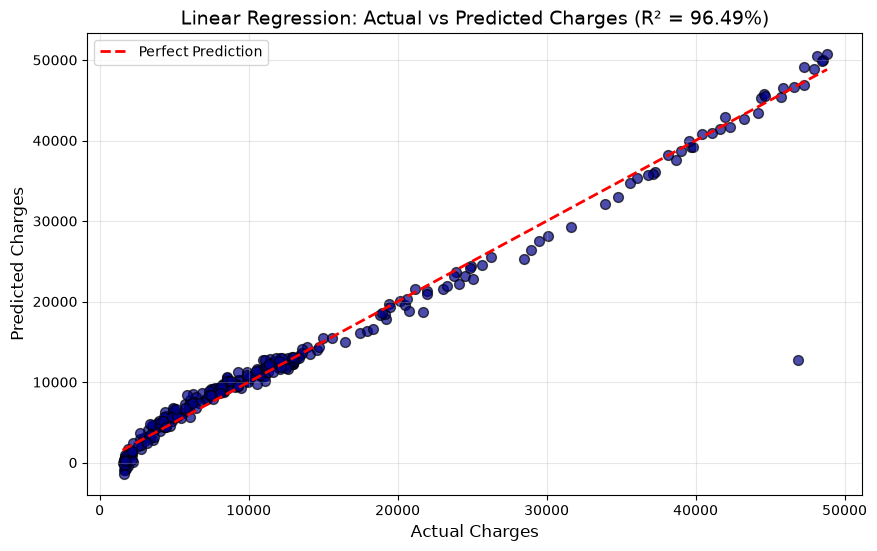

In [93]:

y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, color='darkblue', alpha=0.7, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Charges', fontsize=12)
plt.ylabel('Predicted Charges', fontsize=12)
plt.title('Linear Regression: Actual vs Predicted Charges (R² = 96.49%)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()   

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(y=df['charges'], color='skyblue',linewidth=2)
